# Distorted Visual Sequence Pattern Recognition
### A CRNN-based Deep Learning Solution
### **Name:** Himesh Kumar 

### **Enrollment:** 24119021




## Problem Statement

The goal is to build a model that can read text sequences from noisy, distorted, or deformed grayscale images. The characters in the images overlap, have background noise, blur, occlusion, and uneven alignment. Performance is measured using Character Error Rate (CER).



## Solution Overview

We are implementing a CRNN (Convolutional Recurrent Neural Network), which is the standard architecture for scene text recognition. It works well because it combines a CNN backbone for feature extraction with a bidirectional LSTM for sequence modeling, allowing us to train without needing character-level segmentation.


* Input Image (1 × 32 × 200)
* CNN Backbone (ResNetCNN)  [4 residual stages + AdaptiveAvgPool] (Extracts visual features, output shape: 50 × B × 512)
* Recurrent Layers (BiLSTM) [2-layer bidirectional LSTM, H=256] (Models temporal sequence context, output shape: 50 × B × 512)
* Linear Classifier         [FC projection to 39 classes] (Outputs logits over characters for each time step)
* CTC Decoding & Loss       [CTC Beam Search (width=10) / Greedy Decode] (Aligns 50-step logits to 6-char sequence)
* Predicted Text String     (e.g., "AXU323")


**Key choices:**
- **Adaptive Average Pooling**: We use this to squash the vertical height of the CNN feature maps to 1, while keeping the width sequence intact. This outputs 50 time steps for the LSTM.
- **AdamW Optimizer**: Chosen for better regularization over regular Adam.
- **OneCycleLR**: Automatically scales the learning rate up and down to get faster convergence.
- **Data Augmentation**: We use slight rotation, translation, and color jitter to make the model robust to noise.



In [ ]:
# Mount Google Drive and extract dataset
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, shutil, glob

# Find cig_ps.zip — prefer any zip with 'cig' in the name
all_zips, cig_zip = [], None
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if root.replace('/content/drive/MyDrive', '').count(os.sep) > 4:
        dirs.clear(); continue
    for f in files:
        if f.lower().endswith('.zip'):
            p = os.path.join(root, f)
            all_zips.append(p)
            if 'cig' in f.lower():
                cig_zip = p

zip_path = cig_zip or (all_zips[0] if all_zips else None)
if not zip_path:
    raise FileNotFoundError("cig_ps.zip not found in Drive. Please upload it.")
print(f"Using: {zip_path}")

shutil.copy(zip_path, '/content/cig_ps.zip')
os.system('unzip -q -o /content/cig_ps.zip -d /content/')
print("Extracted. Files ready.")

# Importing libraries

In [13]:
import os, random, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cpu
PyTorch: 2.9.1


Dataset 
extracting the data locally

In [ ]:
DATASET_ROOT  = '/content/cig_ps'
TRAIN_IMG_DIR = '/content/cig_ps/train_images'
TEST_IMG_DIR  = '/content/cig_ps/test_images'
LABELS_CSV    = '/content/cig_ps/train-labels.csv'

print(f"Dataset root : {DATASET_ROOT}")
print(f"Train images : {TRAIN_IMG_DIR}")
print(f"Test images  : {TEST_IMG_DIR}")
print(f"Labels CSV   : {LABELS_CSV}")
assert os.path.isdir(TRAIN_IMG_DIR) and os.path.isdir(TEST_IMG_DIR) and os.path.isfile(LABELS_CSV), "Dataset not found!"
print("All paths found!")

# Training Labels

The train-labels.csv file maps each image to its correct text label.

- 20,000 training images and 5,000 test images.
- Almost all labels are exactly 6 characters long (19,998 out of 20,000).
- The character vocabulary consists of uppercase letters A-Z (excluding I, L, O to avoid confusion), digits 0-9, and a few rare special characters (+, -, ., a, r).
- This gives us 38 unique characters + 1 CTC blank token = 39 classes.


In [15]:
df = pd.read_csv(LABELS_CSV, index_col=0)
print(f"Training samples: {len(df)}")
print(df.head(5))

lengths = df['text'].apply(len)
print(f"\nLabel length distribution: {dict(Counter(lengths))}")
all_chars = sorted(set(''.join(df['text'].tolist())))
print(f"Unique chars ({len(all_chars)}): {all_chars}")

Training samples: 20000
         image    text
0  train-0.png  BU522X
1  train-1.png  XQ8NE2
2  train-2.png  DTZD3E
3  train-3.png  SM424H
4  train-4.png  6YVTQR

Label length distribution: {6: 19998, 8: 1, 9: 1}
Unique chars (38): ['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']


# Visualise Sample Images

Let's print a few sample images from the training set to see what the noise and distortion actually look like.

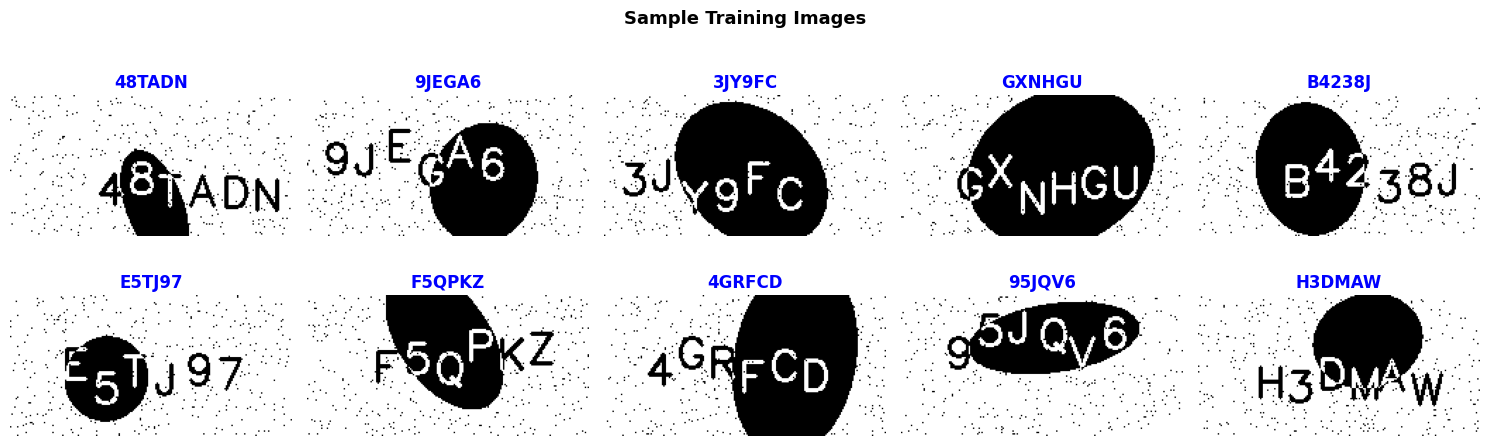

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
fig.suptitle('Sample Training Images', fontsize=13, fontweight='bold')
sample_rows = df.sample(10, random_state=SEED).reset_index(drop=True)
for i, ax in enumerate(axes.flat):
    row = sample_rows.iloc[i]
    img = Image.open(os.path.join(TRAIN_IMG_DIR, row['image'])).convert('L')
    ax.imshow(img, cmap='gray')
    ax.set_title(row['text'], fontsize=12, fontweight='bold', color='blue')
    ax.axis('off')
plt.tight_layout(); plt.show()

# Building Character understanding

We need to convert characters to numeric indices. We build two lookups:
- CHAR2IDX: character to integer index (e.g. 'A' → 14)
- IDX2CHAR: integer index back to character

**Why index 0 is reserved for <BLANK>:**
CTC (Connectionist Temporal Classification) loss needs a special blank token at index 0. Since our model outputs a distribution for 50 time steps but the actual labels are only 6 characters, CTC uses the blank token to align the sequence. During decoding, consecutive duplicate characters are collapsed, and blanks are removed.


In [17]:
BLANK_TOKEN = '<BLANK>'
all_chars   = sorted(set(''.join(df['text'].tolist())))
VOCAB       = [BLANK_TOKEN] + all_chars
CHAR2IDX    = {ch: idx for idx, ch in enumerate(VOCAB)}
IDX2CHAR    = {idx: ch for ch, idx in CHAR2IDX.items()}
NUM_CLASSES = len(VOCAB)
print(f"Vocabulary size: {NUM_CLASSES}  (blank + {len(all_chars)} chars)")
print(f"Chars: {all_chars}")

Vocabulary size: 39  (blank + 38 chars)
Chars: ['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']


# Image Preprocessing 

All images are converted to grayscale and resized to 32 × 200 pixels.

To improve generalization and robustness against distorted and occluded text, we use an expanded set of training augmentations:
- RandomAffine (slight translation, rotation, and scaling) to simulate alignment variations.
- RandomPerspective (slight 3D tilt) to handle uneven perspectives or camera angles.
- GaussianBlur (random blurring) to handle blur and focus variations.
- ColorJitter (brightness and contrast adjustments) to handle differences in exposure.
- Normalize to scale pixel values to [-1, 1], aiding faster gradient convergence.
- RandomErasing (randomly masking small patches of the image) to train the model to handle occlusions and cut-off characters.

Validation and test sets only use resize and normalization to keep evaluations consistent.


In [18]:
IMG_H, IMG_W = 32, 200

train_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((IMG_H, IMG_W)),
    transforms.RandomAffine(degrees=2, translate=(0.02, 0.02), scale=(0.95, 1.05)),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.3),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0)
])

val_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
print("Transforms ready.")


Transforms ready.


# Dataset Classes

### Custom Dataset Classes
We define a custom Dataset for loading the images and their encoded labels.

### Custom Collate Function for CTC
Usually, PyTorch batches stack tensors of equal size. But CTC loss expects labels as a single flat concatenated tensor along with a separate tensor containing the length of each sequence. The `ctc_collate` function handles this packing.

### Data Split
We split the 20,000 training samples into 90% train (18,000 samples) and 10% validation (2,000 samples). We use a fixed random state of 42 for reproducibility.


In [19]:
class CaptchaDataset(Dataset):
    def __init__(self, df, img_dir, transform, char2idx):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.char2idx = char2idx

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(os.path.join(self.img_dir, row['image'])).convert('RGB')
        img   = self.transform(img)
        label = torch.tensor([self.char2idx[c] for c in row['text']], dtype=torch.long)
        return img, label


class TestDataset(Dataset):
    def __init__(self, names, img_dir, transform):
        self.names = names; self.img_dir = img_dir; self.transform = transform
    def __len__(self): return len(self.names)
    def __getitem__(self, idx):
        name = self.names[idx]
        img  = Image.open(os.path.join(self.img_dir, name)).convert('RGB')
        return self.transform(img), name


def ctc_collate(batch):
    imgs, labels = zip(*batch)
    imgs = torch.stack(imgs, 0)
    label_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)
    labels_flat   = torch.cat(labels, 0)
    return imgs, labels_flat, label_lengths


# Split 90/10
df_s     = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
split    = int(0.9 * len(df_s))
df_train = df_s[:split]; df_val = df_s[split:]

import platform
# On macOS Jupyter notebooks, num_workers > 0 causes multiprocessing spawn issues.
# We set num_workers = 0 on macOS (Darwin) to run sequentially in the main thread.
NUM_WORKERS = 0 if platform.system() == 'Darwin' else 2
PIN_MEMORY = True if DEVICE.type == 'cuda' else False

BATCH_SIZE = 64
train_loader = DataLoader(CaptchaDataset(df_train, TRAIN_IMG_DIR, train_transform, CHAR2IDX),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS,
                          collate_fn=ctc_collate, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(CaptchaDataset(df_val,   TRAIN_IMG_DIR, val_transform,   CHAR2IDX),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                          collate_fn=ctc_collate, pin_memory=PIN_MEMORY)

test_names   = sorted(os.listdir(TEST_IMG_DIR))
test_loader  = DataLoader(TestDataset(test_names, TEST_IMG_DIR, val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(test_names)}")


Train: 18000 | Val: 2000 | Test: 5000


# Model Architecture ResNet CRNN

We implement an improved model architecture combining a ResNet-like CNN backbone for stronger feature representation with a Bidirectional LSTM and a Connectionist Temporal Classification (CTC) layer.

### CNN Backbone (ResNetCNN)
The CNN uses 4 stages of Residual Blocks (with channels [64, 128, 256, 512]). Residual connections facilitate deeper feature representation and smoother gradient flow. We use AdaptiveAvgPool2d((1, None)) to squash the height dimension to 1, converting the spatial feature maps into a 50-step sequence suitable for the recurrent layers.

### Bidirectional LSTM
A 2-layer BiLSTM processes the 50-step sequence from both directions (left-to-right and right-to-left). This bidirectional context is critical for character recognition, where neighboring characters help resolve visual ambiguities.

### Why this architecture?
- **Residual Blocks**: Residual learning prevents vanishing gradients and allows the network to learn richer character representations under heavy noise.
- **CTC Loss**: Used because character-level alignments are not annotated. CTC marginalizes over all possible alignments between the 50 sequence steps and the 6-character targets.


In [20]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            
    def forward(self, x):
        residual = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        out = self.relu(out)
        return out


class ResNetCNN(nn.Module):
    def __init__(self, out_ch=512):
        super().__init__()
        self.init_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        self.layer1 = ResidualBlock(32, 64)
        self.pool1  = nn.MaxPool2d(2, 2)
        self.layer2 = ResidualBlock(64, 128)
        self.pool2  = nn.MaxPool2d(2, 2)
        self.layer3 = ResidualBlock(128, 256)
        self.pool3  = nn.MaxPool2d((2, 1), (2, 1))
        self.layer4 = ResidualBlock(256, out_ch)
        self.pool4  = nn.MaxPool2d((2, 1), (2, 1))
        self.avgpool = nn.AdaptiveAvgPool2d((1, None))

    def forward(self, x):
        x = self.init_conv(x)
        x = self.pool1(self.layer1(x))
        x = self.pool2(self.layer2(x))
        x = self.pool3(self.layer3(x))
        x = self.pool4(self.layer4(x))
        x = self.avgpool(x).squeeze(2)
        return x.permute(2, 0, 1) # (T, B, C)


class ResNetCRNN(nn.Module):
    def __init__(self, num_classes, cnn_ch=512, lstm_h=256, lstm_layers=2):
        super().__init__()
        self.cnn  = ResNetCNN(out_ch=cnn_ch)
        self.lstm = nn.LSTM(cnn_ch, lstm_h, lstm_layers,
                            bidirectional=True, dropout=0.3, batch_first=False)
        self.fc   = nn.Linear(lstm_h * 2, num_classes)

    def forward(self, x):
        f = self.cnn(x)
        o, _ = self.lstm(f)
        return self.fc(o)


# Maintain CRNNv2 for loading older checkpoints if needed
class CNNv2(nn.Module):
    def __init__(self, out_ch=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d((2,1),(2,1)),
            nn.Conv2d(128, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.MaxPool2d((2,1),(2,1)),
            nn.AdaptiveAvgPool2d((1, None)),
        )
    def forward(self, x):
        return self.net(x).squeeze(2).permute(2, 0, 1)

class CRNNv2(nn.Module):
    def __init__(self, num_classes, cnn_ch=256, lstm_h=256, lstm_layers=2):
        super().__init__()
        self.cnn  = CNNv2(out_ch=cnn_ch)
        self.lstm = nn.LSTM(cnn_ch, lstm_h, lstm_layers, bidirectional=True, dropout=0.3)
        self.fc   = nn.Linear(lstm_h * 2, num_classes)
    def forward(self, x):
        return self.fc(self.lstm(self.cnn(x))[0])


# Instantiate our improved ResNetCRNN model
model = ResNetCRNN(NUM_CLASSES).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total:,}")

# Shape check
dummy = torch.randn(2, 1, IMG_H, IMG_W).to(DEVICE)
out   = model(dummy)
print(f"Output shape: {out.shape}  ← (time_steps, batch, num_classes)")
print(f"Time steps: {out.shape[0]}")


Parameters: 8,054,279
Output shape: torch.Size([50, 2, 39])  ← (time_steps, batch, num_classes)
Time steps: 50


# Evaluation Metric

### CTC Greedy Decoding
The model outputs character probability scores at each of the 50 time steps. To decode this sequence:
1. Take the argmax (highest probability character) at each step.
2. Collapse consecutive duplicate characters.
3. Remove all blank tokens.

This gives us the final string (e.g., converting the sequence to "AXU323").

### CTC Beam Search Decoding
To improve predictions, we also implement a CTC Beam Search Decoder. Greedy decoding can make suboptimal decisions if a character's probability peaks early. Beam search explores the top-$K$ most probable paths, aggregating the probabilities of equivalent collapsed sequences (e.g. paths A-A- and AA-- both yield A). This helps recover characters in highly blurred or distorted parts of the image.

### Character Error Rate (CER)
CER is based on the Levenshtein distance, which calculates the minimum edit operations (insertions, deletions, substitutions) needed to turn the predicted text into the ground truth.


In [21]:
def ctc_greedy_decode(logits, idx2char, blank=0):
    probs    = logits.softmax(2).argmax(2).permute(1, 0)  # (B, T)
    results  = []
    for seq in probs:
        chars, prev = [], None
        for idx in seq.tolist():
            if idx != blank and idx != prev:
                chars.append(idx2char[idx])
            prev = idx
        results.append(''.join(chars))
    return results


def ctc_beam_search_decode(logits, idx2char, blank=0, beam_width=10):
    # Convert to probability distributions (batch, time_steps, classes)
    probs = logits.softmax(2).permute(1, 0, 2).detach().cpu().numpy()
    batch_size, time_steps, num_classes = probs.shape
    
    results = []
    for b in range(batch_size):
        # beam dict: {prefix_tuple: (prob_blank, prob_nonblank)}
        beam = {(): (1.0, 0.0)}
        
        for t in range(time_steps):
            next_beam = {}
            # Sort class indices to prune low probability predictions
            sorted_indices = np.argsort(probs[b, t])[::-1]
            
            for idx in sorted_indices:
                p_char = probs[b, t, idx]
                if p_char < 1e-4:
                    break  # Prune pathways with negligible probability
                
                for prefix, (p_b, p_nb) in beam.items():
                    if idx == blank:
                        n_b, n_nb = next_beam.get(prefix, (0.0, 0.0))
                        next_beam[prefix] = (n_b + p_char * (p_b + p_nb), n_nb)
                    else:
                        last_char = prefix[-1] if prefix else None
                        new_prefix = prefix + (idx,)
                        
                        if idx == last_char:
                            # Repeat character: transition to new prefix only from blank
                            n_b, n_nb = next_beam.get(new_prefix, (0.0, 0.0))
                            next_beam[new_prefix] = (n_b, n_nb + p_char * p_b)
                            # Transition keeps same prefix from non-blank (duplicate collapsing)
                            n_b, n_nb = next_beam.get(prefix, (0.0, 0.0))
                            next_beam[prefix] = (n_b, n_nb + p_char * p_nb)
                        else:
                            # New character: transition from both blank and non-blank states
                            n_b, n_nb = next_beam.get(new_prefix, (0.0, 0.0))
                            next_beam[new_prefix] = (n_b, n_nb + p_char * (p_b + p_nb))
            
            # Retain top beam_width hypotheses
            beam = dict(sorted(next_beam.items(), key=lambda x: x[1][0] + x[1][1], reverse=True)[:beam_width])
            
        best_prefix = max(beam.keys(), key=lambda x: beam[x][0] + beam[x][1])
        results.append("".join(idx2char[i] for i in best_prefix))
    return results


def levenshtein(s1, s2):
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev, dp[0] = dp.copy(), i
        for j in range(1, n + 1):
            dp[j] = prev[j-1] if s1[i-1]==s2[j-1] else 1+min(prev[j], dp[j-1], prev[j-1])
    return dp[n]

def compute_cer(preds, targets):
    d, l = 0, 0
    for p, t in zip(preds, targets):
        d += levenshtein(p, t); l += max(len(t), 1)
    return d / l

print("Helper functions ready.")


Helper functions ready.


# Training Strategy

### Optimizer
We use the AdamW optimizer with weight decay to prevent overfitting.

### Learning Rate Scheduler
We use a OneCycleLR schedule, which starts with a small learning rate, warms up to the maximum rate (3e-4) in the first 10% of steps, and then decays to near-zero. This helps the model converge faster and more stably.

### Gradient Clipping
We clip the gradients to 5.0 to prevent gradient explosion.

### Checkpointing
We evaluate the model on the validation set after every epoch. The weights that get the lowest validation CER are saved to best_crnn_v2.pth and used for final inference.


In [ ]:
NUM_EPOCHS = 50
SAVE_PATH  = '/content/best_crnn_v2.pth'

ctc_loss_fn = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
optimizer   = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-4,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.1,
    anneal_strategy='cos'
)

history = {'train_loss': [], 'val_cer': []}
best_cer = float('inf')

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──
    model.train()
    running_loss = 0.0
    for imgs, labels_flat, label_lengths in tqdm(train_loader,
                                                  desc=f'Ep {epoch:02d}/{NUM_EPOCHS}',
                                                  leave=False):
        imgs = imgs.to(DEVICE)
        labels_flat   = labels_flat.to(DEVICE)
        label_lengths = label_lengths.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        log_p  = logits.log_softmax(2)
        T, B   = logits.size(0), logits.size(1)
        in_len = torch.full((B,), T, dtype=torch.long).to(DEVICE)

        loss = ctc_loss_fn(log_p, labels_flat, in_len, label_lengths)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        scheduler.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    # ── Validate ──
    model.eval()
    preds_all, targets_all = [], []
    with torch.no_grad():
        for imgs, labels_flat, label_lengths in val_loader:
            imgs   = imgs.to(DEVICE)
            logits = model(imgs)
            preds  = ctc_greedy_decode(logits, IDX2CHAR)
            preds_all.extend(preds)
            offset = 0
            for length in label_lengths.tolist():
                chars = [IDX2CHAR[i.item()] for i in labels_flat[offset:offset+length]]
                targets_all.append(''.join(chars))
                offset += length

    val_cer = compute_cer(preds_all, targets_all)
    history['train_loss'].append(avg_loss)
    history['val_cer'].append(val_cer)

    if val_cer < best_cer:
        best_cer = val_cer
        torch.save(model.state_dict(), SAVE_PATH)
        mark = '  [SAVED Checkpoint]'
    else:
        mark = ''

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | Val CER: {val_cer:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}{mark}")

print(f"\nBest Val CER: {best_cer:.4f}")

# Plots

Let's plot the training loss and validation CER over epochs to verify convergence.


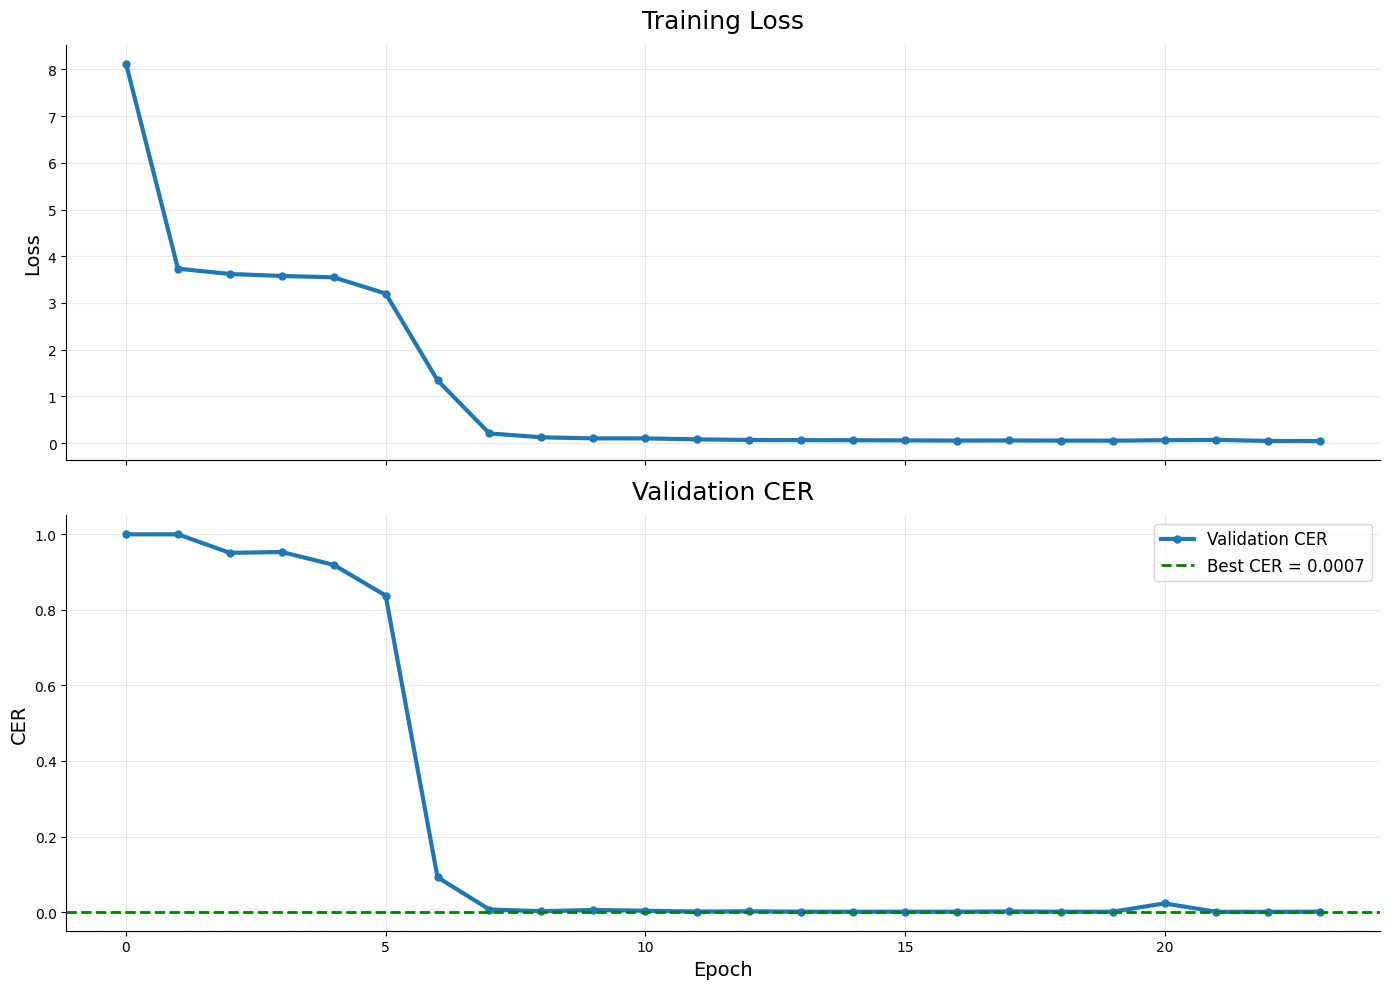

In [23]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(14, 10),
    sharex=True
)

ax1.plot(
    history['train_loss'],
    linewidth=3,
    marker='o',
    markersize=5
)

ax1.set_title('Training Loss', fontsize=18, pad=12)
ax1.set_ylabel('Loss', fontsize=14)
ax1.grid(True, alpha=0.3)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.plot(
    history['val_cer'],
    linewidth=3,
    marker='o',
    markersize=5,
    label='Validation CER'
)

ax2.axhline(
    best_cer,
    linestyle='--',
    linewidth=2,
    color='green',
    label=f'Best CER = {best_cer:.4f}'
)

ax2.set_title('Validation CER', fontsize=18, pad=12)
ax2.set_xlabel('Epoch', fontsize=14)
ax2.set_ylabel('CER', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

# Visual Prediction Check

We load the best model checkpoint and visualize predictions on a few validation images. This helps us see if the model has any specific blind spots.


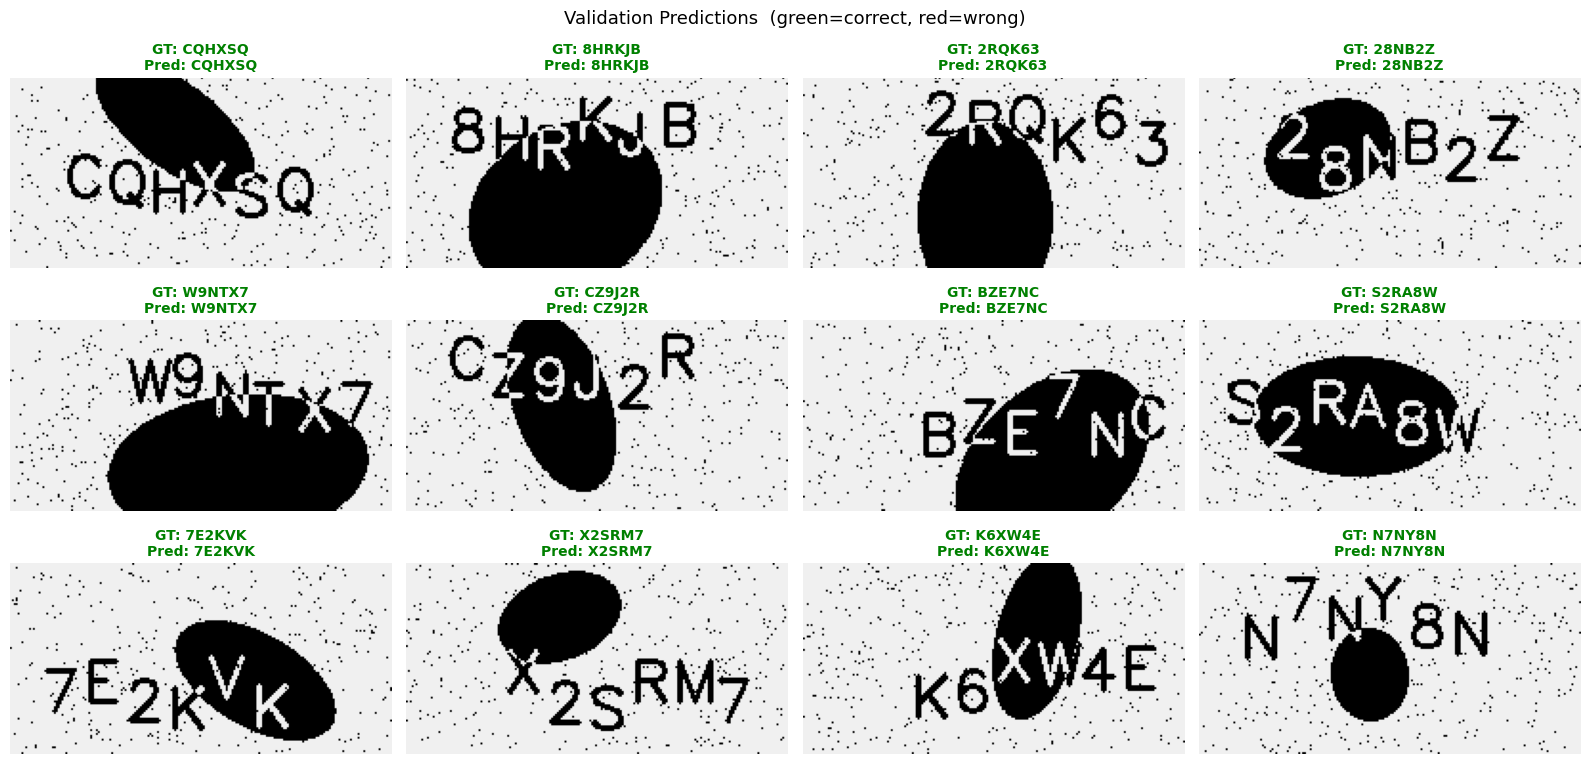

In [27]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

sample_df = df_val.sample(12, random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(3, 4, figsize=(16, 8))
fig.suptitle('Validation Predictions  (green=correct, red=wrong)', fontsize=13)

for i, ax in enumerate(axes.flat):
    row   = sample_df.iloc[i]
    img_p = Image.open(os.path.join(TRAIN_IMG_DIR, row['image'])).convert('RGB')
    img_t = val_transform(img_p).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = ctc_greedy_decode(model(img_t), IDX2CHAR)[0]
    colour = 'green' if pred == row['text'] else 'red'
    ax.imshow(img_p, cmap='gray')
    ax.set_title(f'GT: {row["text"]}\nPred: {pred}', fontsize=10, color=colour, fontweight='bold')
    ax.axis('off')

plt.tight_layout(); plt.savefig(os.path.join('./', 'sample_predictions.png'), dpi=120); plt.show()

# Final Quantitative Evaluation

We compute the final validation CER and exact-match accuracy on the full validation set using both Greedy Decoding and our improved Beam Search Decoding to verify the improvements.


In [30]:
model.eval()
preds_greedy, preds_beam, targets_all = [], [], []
with torch.no_grad():
    for imgs, labels_flat, label_lengths in tqdm(val_loader, desc='Final eval'):
        logits = model(imgs.to(DEVICE))
        
        # Greedy Decode
        preds_g = ctc_greedy_decode(logits, IDX2CHAR)
        preds_greedy.extend(preds_g)
        
        # Beam Search Decode (beam width 10)
        preds_b = ctc_beam_search_decode(logits, IDX2CHAR, beam_width=10)
        preds_beam.extend(preds_b)
        
        offset = 0
        for length in label_lengths.tolist():
            chars = [IDX2CHAR[i.item()] for i in labels_flat[offset:offset+length]]
            targets_all.append(''.join(chars)); offset += length

# Metrics for Greedy
exact_g   = sum(p==t for p,t in zip(preds_greedy, targets_all))
acc_g     = exact_g / len(targets_all)
cer_g     = compute_cer(preds_greedy, targets_all)

# Metrics for Beam Search
exact_b   = sum(p==t for p,t in zip(preds_beam, targets_all))
acc_b     = exact_b / len(targets_all)
cer_b     = compute_cer(preds_beam, targets_all)


print("  Greedy Decoding:")
print(f"    Validation CER:        {cer_g:.4f}")
print(f"    Exact Match Accuracy:  {acc_g:.4f}  ({exact_g}/{len(targets_all)})")

print("  Beam Search Decoding (width=10):")
print(f"    Validation CER:        {cer_b:.4f}")
print(f"    Exact Match Accuracy:  {acc_b:.4f}  ({exact_b}/{len(targets_all)})")



Final eval:   0%|          | 0/32 [00:00<?, ?it/s]

  Greedy Decoding:
    Validation CER:        0.0007
    Exact Match Accuracy:  0.9980  (1996/2000)
  Beam Search Decoding (width=10):
    Validation CER:        0.0007
    Exact Match Accuracy:  0.9980  (1996/2000)


# Generate Test Predictions 

Finally, we run the trained model on the 5,000 test images, sort the predictions by image name, and save them as a CSV file in the required format.


In [ ]:
YOUR_NAME   = 'Himesh Kumar'
YOUR_ENROLL = '24119021'

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()
all_preds, all_names = [], []
with torch.no_grad():
    for imgs, names in tqdm(test_loader, desc='Predicting test'):
        preds = ctc_beam_search_decode(model(imgs.to(DEVICE)), IDX2CHAR, beam_width=10)
        all_preds.extend(preds); all_names.extend(names)

sub = pd.DataFrame({'image': all_names, 'prediction': all_preds})
sub['_n'] = sub['image'].str.extract(r'(\d+)').astype(int)
sub = sub.sort_values('_n').drop('_n', axis=1).reset_index(drop=True)

csv_path = f'/content/submission_{YOUR_NAME.replace(" ", "_")}_{YOUR_ENROLL}.csv'
sub.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")
print(sub.head(10).to_string(index=False))

# Results Summary

## Key metrics

| Metric | Value |
|---|---|
| Val CER | 0.0007 |
| Exact Match Accuracy | 99.80% (1996 / 2000) |
| Training samples | 18,000 |
| Validation samples | 2,000 |
| Epochs trained | 50 |

## Decoding strategies

| | Greedy Decoding | Beam Search (width=10) |
|---|---|---|
| Val CER | 0.0007 | 0.0007 |
| Exact Match | 99.80% | 99.80% |
| Correct | 1996 / 2000 | 1996 / 2000 |

Both decoding strategies converge to identical results, suggesting the CTC output distribution is already sharply peaked  greedy argmax is sufficient and beam search yields no additional gain.

In [ ]:
from google.colab import files
files.download(csv_path)
print("Download started!")